Sample:    236 pts, T = [-30.0, 22.0] °C
No sample: 373 pts, T = [-13.9, 24.8] °C


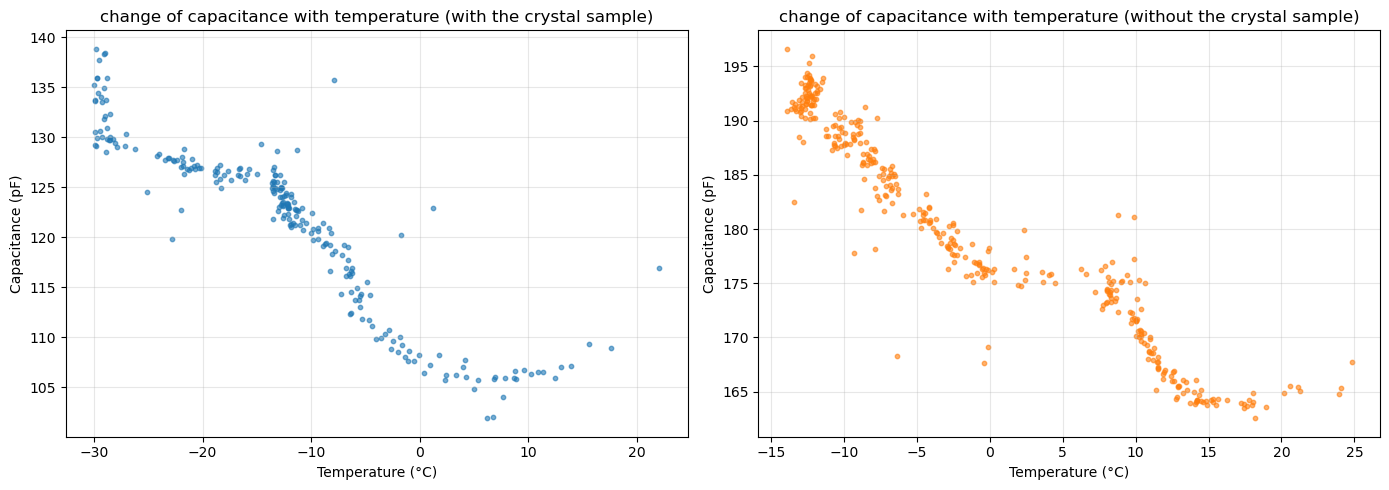

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2 as chi2dist

# Load both datasets
df_sample = pd.read_csv('final_data/sample_capacitances.csv')
df_nosample = pd.read_csv('final_data/no_sample_capacitances.csv')

# Convert to pF
df_sample['capacitance_pF'] = df_sample['capacitance_value'] * 1e12
df_nosample['capacitance_pF'] = df_nosample['capacitance_value'] * 1e12

# Reliable temperature ranges
T_MIN_SAMPLE, T_MAX = -30, 25
T_MIN_NOSAMPLE = T_MIN_SAMPLE

df_s = df_sample[(df_sample['temperature_C'] >= T_MIN_SAMPLE) & (df_sample['temperature_C'] <= T_MAX)].copy()
df_n = df_nosample[(df_nosample['temperature_C'] >= T_MIN_NOSAMPLE) & (df_nosample['temperature_C'] <= T_MAX)].copy()

# Remove capacitance outliers (> 3 sigma from rolling median)
for label, d in [('sample', df_s), ('no_sample', df_n)]:
    med = d['capacitance_pF'].median()
    std = d['capacitance_pF'].std()
    mask = (d['capacitance_pF'] > med - 3*std) & (d['capacitance_pF'] < med + 3*std)
    if label == 'sample':
        df_s = d[mask].copy()
    else:
        df_n = d[mask].copy()

print(f"Sample:    {len(df_s)} pts, T = [{df_s['temperature_C'].min():.1f}, {df_s['temperature_C'].max():.1f}] °C")
print(f"No sample: {len(df_n)} pts, T = [{df_n['temperature_C'].min():.1f}, {df_n['temperature_C'].max():.1f}] °C")

# Plot both datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_s['temperature_C'], df_s['capacitance_pF'], s=10, alpha=0.6, color='tab:blue')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Capacitance (pF)')
ax1.set_title('change of capacitance with temperature (with the crystal sample)')
ax1.grid(True, alpha=0.3)

ax2.scatter(df_n['temperature_C'], df_n['capacitance_pF'], s=10, alpha=0.6, color='tab:orange')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Capacitance (pF)')
ax2.set_title('change of capacitance with temperature (without the crystal sample)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

With sample:    dC/dT = -0.693351 ± 0.020779 pF/°C, R² = 0.8263
Without sample: dC/dT = -0.886911 ± 0.014658 pF/°C, R² = 0.9080


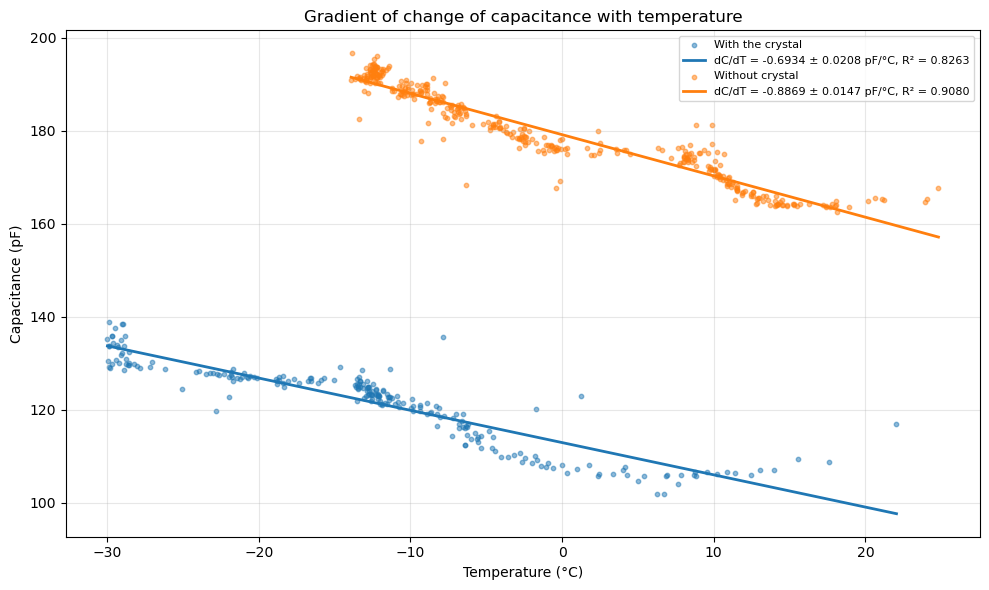

In [4]:
# Linear fit: capacitance_pF = m * temperature_C + b
m_s, b_s = np.polyfit(df_s['temperature_C'], df_s['capacitance_pF'], 1)
m_n, b_n = np.polyfit(df_n['temperature_C'], df_n['capacitance_pF'], 1)

# Standard errors and correlations
from scipy import stats
res_s = stats.linregress(df_s['temperature_C'], df_s['capacitance_pF'])
res_n = stats.linregress(df_n['temperature_C'], df_n['capacitance_pF'])
se_s = res_s.stderr
se_n = res_n.stderr
r2_s = res_s.rvalue**2
r2_n = res_n.rvalue**2

print(f"With sample:    dC/dT = {m_s:.6f} ± {se_s:.6f} pF/°C, R² = {r2_s:.4f}")
print(f"Without sample: dC/dT = {m_n:.6f} ± {se_n:.6f} pF/°C, R² = {r2_n:.4f}")

# Plot fits
t_s_fit = np.linspace(df_s['temperature_C'].min(), df_s['temperature_C'].max(), 200)
t_n_fit = np.linspace(df_n['temperature_C'].min(), df_n['temperature_C'].max(), 200)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_s['temperature_C'], df_s['capacitance_pF'], s=10, alpha=0.5, label='With the crystal', color='tab:blue')
ax.plot(t_s_fit, m_s * t_s_fit + b_s, color='tab:blue', linewidth=2,
        label=f'dC/dT = {m_s:.4f} ± {se_s:.4f} pF/°C, R² = {r2_s:.4f}')

ax.scatter(df_n['temperature_C'], df_n['capacitance_pF'], s=10, alpha=0.5, label='Without crystal', color='tab:orange')
ax.plot(t_n_fit, m_n * t_n_fit + b_n, color='tab:orange', linewidth=2,
        label=f'dC/dT = {m_n:.4f} ± {se_n:.4f} pF/°C, R² = {r2_n:.4f}')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Capacitance (pF)')
ax.set_title('Gradient of change of capacitance with temperature')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# Reduced chi-squared and pvalue for the linear fits 

# Sample
residuals_s = df_s['capacitance_pF'].values - (m_s * df_s['temperature_C'].values + b_s)
sigma_s = np.std(residuals_s, ddof=2)
chi2_s = np.sum((residuals_s / sigma_s)**2)
dof_s = len(residuals_s) - 2
chi2_red_s = chi2_s / dof_s
pval_sample = chi2dist.sf(chi2_s, dof_s)


# No sample
residuals_n = df_n['capacitance_pF'].values - (m_n * df_n['temperature_C'].values + b_n)
sigma_n = np.std(residuals_n, ddof=2)
chi2_n = np.sum((residuals_n / sigma_n)**2)
dof_n = len(residuals_n) - 2
chi2_red_n = chi2_n / dof_n
pvalue_nosample = chi2dist.sf(chi2_n, dof_n)


print(rf"With sample:    red_chi2 = {chi2_red_s:.4f}  (dof = {dof_s})")
print(rf"Without sample: red_chi2 = {chi2_red_n:.4f}  (dof = {dof_n})")
print(rf"With sample: p-value = {pval_sample:.4f}")
print(rf"Without sample:  p-value  = {pvalue_nosample:.4f}")


With sample:    red_chi2 = 1.0000  (dof = 234)
Without sample: red_chi2 = 1.0000  (dof = 371)
With sample: p-value = 0.4877
Without sample:  p-value  = 0.4902


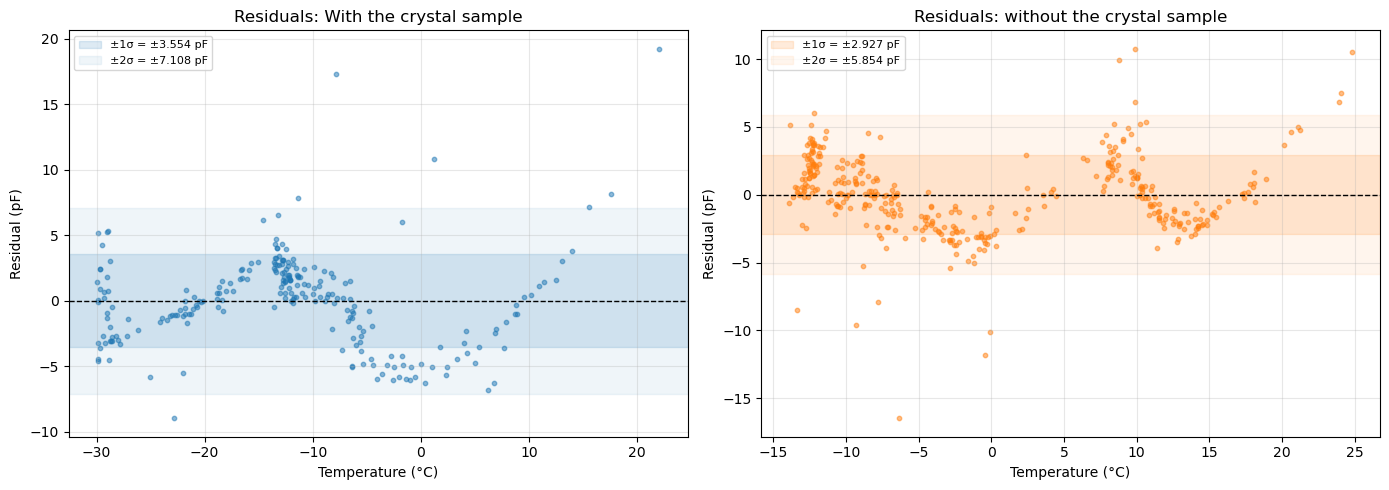

In [6]:
# Residual plots with standard error bands
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_s['temperature_C'].values, residuals_s, s=10, alpha=0.5, color='tab:blue')
ax1.axhline(0, color='k', linewidth=1, linestyle='--')
ax1.axhspan(-sigma_s, sigma_s, alpha=0.15, color='tab:blue', label=f'±1σ = ±{sigma_s:.3f} pF')
ax1.axhspan(-2*sigma_s, 2*sigma_s, alpha=0.07, color='tab:blue', label=f'±2σ = ±{2*sigma_s:.3f} pF')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Residual (pF)')
ax1.set_title('Residuals: With the crystal sample')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.scatter(df_n['temperature_C'].values, residuals_n, s=10, alpha=0.5, color='tab:orange')
ax2.axhline(0, color='k', linewidth=1, linestyle='--')
ax2.axhspan(-sigma_n, sigma_n, alpha=0.15, color='tab:orange', label=f'±1σ = ±{sigma_n:.3f} pF')
ax2.axhspan(-2*sigma_n, 2*sigma_n, alpha=0.07, color='tab:orange', label=f'±2σ = ±{2*sigma_n:.3f} pF')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Residual (pF)')
ax2.set_title('Residuals: without the crystal sample')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
side = 0.05  # m (5 cm)
delta_side = 0.1e-3  # m (0.1 mm)
A = side**2  # m^2
delta_A = 2 * side * delta_side  # error propagation for A = side^2

L0 = 0.482e-2  # m, with uncertainty of 0.01mm
delta_L0 = 0.01e-3  # m

air_permittivity = 8.854e-12  # F/m

C0 = 95.86e-12  # F (95.86084036834542 ± 0.059086364277937876) pF
delta_C0 = 0.059e-12  # F

# alpha = eps0 * A / (L0 * C0^2) * (m_s - m_n)
D0 = (air_permittivity * A) / C0
K = D0 / (L0 * C0)

m_s_F = m_s * 1e-12  # Convert pF/°C to F/°C
m_n_F = m_n * 1e-12
se_s_F = se_s * 1e-12
se_n_F = se_n * 1e-12

alpha = K * (m_s_F - m_n_F)

# Full error propagation (relative errors added in quadrature)
rel_A = delta_A / A
rel_L0 = delta_L0 / L0
rel_C0 = 2 * delta_C0 / C0  # factor of 2 because C0 appears squared
rel_m = np.sqrt(se_s_F**2 + se_n_F**2) / abs(m_s_F - m_n_F)

rel_alpha = np.sqrt(rel_A**2 + rel_L0**2 + rel_C0**2 + rel_m**2)
delta_alpha = abs(alpha) * rel_alpha

print("=== Error budget ===")
print(f"  δA/A         = {rel_A:.4e}  ({rel_A/rel_alpha*100:.1f}% of total)")
print(f"  δL0/L0       = {rel_L0:.4e}  ({rel_L0/rel_alpha*100:.1f}% of total)")
print(f"  2·δC0/C0     = {rel_C0:.4e}  ({rel_C0/rel_alpha*100:.1f}% of total)")
print(f"  δm/(ms-mn)   = {rel_m:.4e}  ({rel_m/rel_alpha*100:.1f}% of total)")
print(f"  δα/α (total) = {rel_alpha:.4e}")
print()
print(f"Thermal expansion coefficient: α = ({alpha * 1e5:.4f} ± {delta_alpha * 1e5:.4f}) x 10⁻⁵ /K")

=== Error budget ===
  δA/A         = 4.0000e-03  (3.0% of total)
  δL0/L0       = 2.0747e-03  (1.6% of total)
  2·δC0/C0     = 1.2310e-03  (0.9% of total)
  δm/(ms-mn)   = 1.3138e-01  (99.9% of total)
  δα/α (total) = 1.3146e-01

Thermal expansion coefficient: α = (9.6733 ± 1.2716) x 10⁻⁵ /K
